In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# 1. Загрузка изображений
def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = cv2.imread(os.path.join(folder, filename))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
    return np.array(images)

In [27]:
# 2. Вычисляем локальную дисперсию
def local_variance(gray, ksize=7):
    gray = gray.astype(np.float32)
    mean = cv2.blur(gray, (ksize, ksize))
    mean_sq = cv2.blur(gray*gray, (ksize, ksize))
    return mean_sq - mean*mean

In [28]:
# 3. Вычисление тернарной маски облаков (0,1,2)
def cloud_mask_ternary(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    # Бинарная маска облаков
    _, mask_v = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, mask_s = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask_bin = cv2.bitwise_and(mask_v, mask_s)
    mask_bin = (mask_bin > 0).astype(np.uint8)

    # Локальная дисперсия
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    var = local_variance(gray, ksize=7)

    cloud_pixels = var[mask_bin == 1]
    if len(cloud_pixels) == 0:
        return mask_bin  # нет облаков == 0

    T = np.percentile(cloud_pixels, 40)  # трешхолд разделения на плотное/полупрозрачное

    tern = np.zeros_like(mask_bin)
    tern[(mask_bin == 1) & (var < T)] = 1   # плотное облако
    tern[(mask_bin == 1) & (var >= T)] = 2  # полупрозрачное облако

    return tern

In [29]:
def build_masks_for_dir(img_massive):
    return np.array([cloud_mask_ternary(img) for img in img_massive])

In [35]:
# 4. Метод ORB нахождения гомографии изображений: ищем преобразование для пар точек с похожими деструкторами
def align_images_orb(img_ref, img):
    """
    Выравнивает img относительно img_ref с помощью ORB + гомографии.
    Возвращает img, приведённое к системе координат img_ref.
    """
    gray_ref = cv2.cvtColor(img_ref, cv2.COLOR_RGB2GRAY)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    orb = cv2.ORB_create(5000)

    kp1, des1 = orb.detectAndCompute(gray_ref, None)
    kp2, des2 = orb.detectAndCompute(gray, None)

    if des1 is None or des2 is None or len(kp1) < 10 or len(kp2) < 10:
        #без выравнивания
        return img, np.eye(3)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    matches = matches[:200]

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC)
    if H is None:
        return img, np.eye(3)

    h, w = img_ref.shape[:2]
    aligned = cv2.warpPerspective(img, H, (w, h))

    return aligned, H

In [31]:
def align_stack_orb(img_massive, mask_massive):
    N = img_massive.shape[0]

    ref_img = img_massive[0]
    H_ref, W_ref = ref_img.shape[:2]

    aligned_imgs = [ref_img]
    aligned_masks = [mask_massive[0]]

    for i in range(1, N):
        img_i = img_massive[i]
        mask_i = mask_massive[i]

        aligned_img, H = align_images_orb(ref_img, img_i)

        # Маску выравниваем той же гомографией
        mask_i_uint8 = mask_i.astype(np.uint8)

        aligned_mask = cv2.warpPerspective(
            mask_i_uint8,
            H,
            (W_ref, H_ref),
            flags=cv2.INTER_NEAREST
        )

        aligned_imgs.append(aligned_img)
        aligned_masks.append(aligned_mask)

    return np.array(aligned_imgs), np.array(aligned_masks)


In [38]:
# 5. subtask2 — сборка карты

def subtask2(img_massive, mask_massive, alpha=0.2):
    N, H, W, C = img_massive.shape

    clean_mask = (mask_massive == 0)
    semi_mask  = (mask_massive == 2)

    clean_mask_4d = clean_mask[..., None]
    semi_mask_4d  = semi_mask[..., None]

    clean_weights = clean_mask_4d.astype(np.float32)
    semi_weights  = semi_mask_4d.astype(np.float32) * alpha

    total_weights = clean_weights + semi_weights
    weighted_sum = img_massive * clean_weights + img_massive * semi_weights

    sum_pixels = weighted_sum.sum(axis=0)
    sum_weights = total_weights.sum(axis=0)

    result_img = np.zeros((H, W, 3), dtype=np.float32)
    white = np.array([255, 255, 255], dtype=np.float32)

    valid = (sum_weights[..., 0] > 0)

    result_img[valid] = (sum_pixels[valid] / sum_weights[valid])
    result_img[~valid] = white

    return result_img.astype(np.uint8)

In [37]:
# 6. Визуализация
def visualize_subtask3(img_massive, mask_massive, result_img, title_prefix=""):
    N = img_massive.shape[0]

    fig, axes = plt.subplots(2, N, figsize=(4*N, 8))

    for i in range(N):
        axes[0, i].imshow(img_massive[i])
        axes[0, i].set_title(f"{title_prefix}Кадр {i}")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask_massive[i], cmap='viridis')
        axes[1, i].set_title(f"{title_prefix}Маска {i} (0/1/2)")
        axes[1, i].axis("off")

    plt.suptitle(f"{title_prefix}Входные изображения и маски", fontsize=16)
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(result_img)
    plt.title(f"{title_prefix}Итоговая карта местности")
    plt.axis("off")
    plt.show()

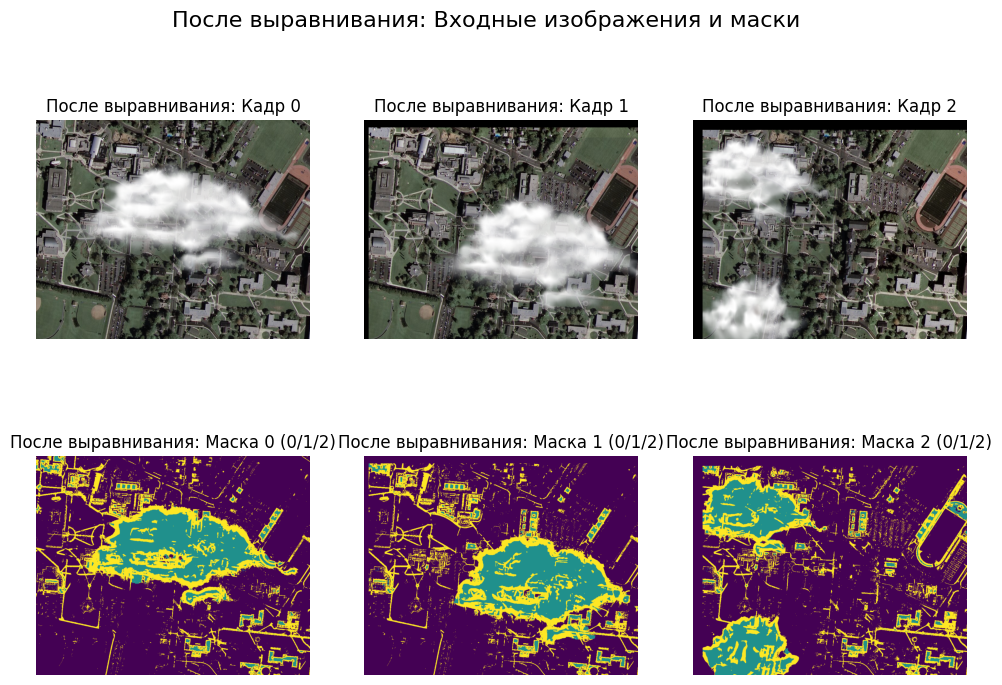

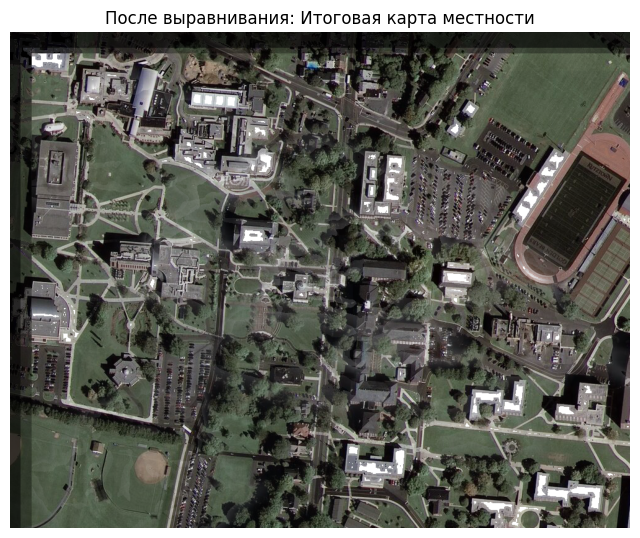

In [44]:
dir3_path = "drive/MyDrive/hackathon_3_problemm/dir3"

# 1. Загружаем изображения
img_massive = load_images_from_folder(dir3_path)

# 2. Строим тернарные маски (0,1,2)
mask_massive = build_masks_for_dir(img_massive)
# 3. Выравниваем все кадры и маски относительно первого
aligned_imgs, aligned_masks = align_stack_orb(img_massive, mask_massive)

# 4. Собираем карту по выровненным кадрам
result_img = subtask2(aligned_imgs, aligned_masks, alpha=0.2)

# 5. Визуализируем
visualize_subtask3(aligned_imgs, aligned_masks, result_img, title_prefix="После выравнивания: ")